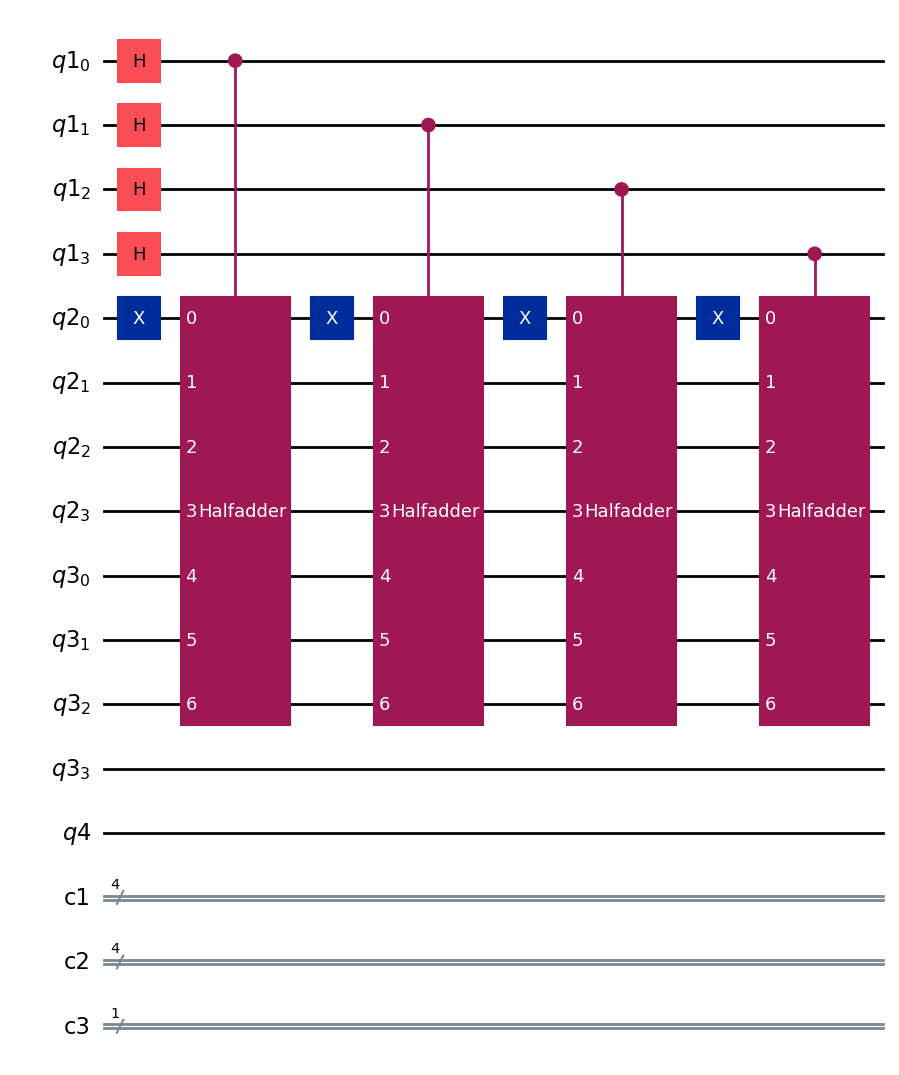

In [ ]:
from qiskit import QuantumCircuit, transpile, QuantumRegister, ClassicalRegister
from qiskit.circuit.library import HalfAdderGate
from qiskit_aer import AerSimulator


def make_circuit (N_COUNT: int) -> QuantumCircuit:
    qr1 = QuantumRegister(N_COUNT, 'q1')
    qr2 = QuantumRegister(N_COUNT, 'q2')
    qr3 = QuantumRegister(N_COUNT, 'q3')
    cl1 = ClassicalRegister(N_COUNT, 'c1')
    cl2 = ClassicalRegister(N_COUNT, 'c2')
    qr4 = QuantumRegister(1, 'q4')
    cl3 = ClassicalRegister(1, 'c3')

    qc = QuantumCircuit(qr1, qr2, qr3, qr4, cl1, cl2, cl3)
    adder = HalfAdderGate(num_state_qubits=N_COUNT-1).control(1)
    for q in range(N_COUNT):
        qc.h(qr1[q])
    for q in range(N_COUNT):
        qc.x(qr2[0])
        qc.append(adder, [q]+list(range(N_COUNT,3*N_COUNT - 1)))
    return qc

qc = make_circuit(4)
qc.draw('mpl')


In [6]:
simulator = AerSimulator()
qcircuit = transpile(qc, simulator)
# counts = result.get_counts(qcircuit)
# plot_histogram(counts, title='Bell-State counts')

In [7]:
result = simulator.run(qcircuit).result()

In [8]:

print(result)
print('untranspiled qc results')
print('gates used: ', dict(qc.count_ops()))
print('total # of gates used: ', sum(dict(qc.count_ops()).values()))
print('number of qubits: ', qc.num_qubits)
print ('transpiled qcircuit results')
print('gates used: ', dict(qcircuit.count_ops()))
print('total # of gates used: ', sum(dict(qcircuit.count_ops()).values()))
print('number of qubits: ', qcircuit.num_qubits)

Result(backend_name='aer_simulator', backend_version='0.17.2', job_id='636da458-c697-4f52-8a5f-cb9c3027e5af', success=True, results=[ExperimentResult(shots=1024, success=True, meas_level=2, data=ExperimentResultData(), header={'creg_sizes': [['c1', 4], ['c2', 4], ['c3', 1]], 'global_phase': 0.0, 'memory_slots': 9, 'n_qubits': 13, 'name': 'circuit-1271', 'qreg_sizes': [['q1', 4], ['q2', 4], ['q3', 4], ['q4', 1]], 'metadata': {}}, status=DONE, seed_simulator=1795539707, metadata={'num_bind_params': 1, 'runtime_parameter_bind': False, 'parallel_state_update': 8, 'parallel_shots': 1, 'batched_shots_optimization': False, 'remapped_qubits': False, 'active_input_qubits': [], 'device': 'CPU', 'time_taken': 3.0084e-05, 'measure_sampling': False, 'num_clbits': 9, 'max_memory_mb': 16384, 'input_qubit_map': [], 'num_qubits': 0, 'method': 'stabilizer', 'required_memory_mb': 0}, time_taken=3.0084e-05)], date=2026-04-29T14:07:08.979731, status=COMPLETED, header=None, qobj_id='', metadata={'time_taken